# LightGBM: Deep Dive
## Loan Default Prediction (HMEQ Dataset)

*Part of the [ML Model Comparison](../loan_default_tradeoff_matrix.html) series on bitterscientist.com*

This notebook covers:
1. The math behind LightGBM (leaf-wise growth, GOSS, EFB, histogram-based splitting)
2. Worked examples using actual HMEQ data
3. Model training with hyperparameter tuning
4. Diagnostic visualizations (exported as interactive plotly HTML)
5. Results interpretation

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, ".")
from shared_utils import *

# Additional imports
from lightgbm import LGBMClassifier
import ast

MODEL_NAME = "LightGBM"
MODEL_SLUG = "lightgbm"

# Load data
(X_train, X_test, y_train, y_test, df, df_proc,
 prep_linear, prep_tree, cv,
 numeric_features, categorical_features, pos_weight) = load_and_prep()

Dataset loaded: 5960 rows, 13 columns
Default rate: 19.95%
Train: 4470 | Test: 1490
Numeric features: 15 | Categorical: 2
Positive class weight: 4.01


---
## 2. The Math Behind LightGBM

### 2.1 The Core Idea

LightGBM (Light Gradient Boosting Machine) is a modern gradient boosting framework optimized for speed and accuracy. While standard gradient boosting trains trees **level-by-level** (breadth-first), LightGBM uses **leaf-wise (best-first)** growth: at each iteration, it splits the leaf with the maximum loss reduction, regardless of depth.

The key innovation: **Focus on the leaves that matter most**, not on balancing tree depth. This can reduce loss faster per iteration, but requires careful regularization to avoid overfitting.

### 2.2 Gradient Boosting Foundation

Like all gradient boosting methods, LightGBM solves:

$$\min_{F} \sum_{i=1}^{n} L(y_i, F(x_i))$$

by building trees sequentially. After $t$ trees, the residuals (or pseudo-residuals for classification) are:

$$r_i^{(t)} = -\frac{\partial L(y_i, F_{t-1}(x_i))}{\partial F_{t-1}(x_i)}$$

The next tree $h_t$ is trained to fit these residuals:

$$F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$$

where $\eta$ is the learning rate (shrinkage). In classification, the loss is typically **log loss** (binary cross-entropy).

### 2.3 Leaf-Wise vs Level-Wise Growth

**Level-Wise (Standard Gradient Boosting):**
- Each iteration splits all leaves at the same depth level
- Produces balanced trees
- Pros: Stable, less overfitting risk
- Cons: May split leaves with small loss reduction

**Leaf-Wise (LightGBM Default):**
- At each iteration, split the single leaf with maximum loss reduction
- Produces imbalanced, deeper trees
- Pros: Focuses on high-impact splits, reduces loss faster per iteration
- Cons: Can overfit if not regularized; requires `max_depth` and `num_leaves` control

Mathematically, both choose the best split $(j, t)$ for feature $j$ at threshold $t$ by minimizing the sum of squared residuals in the resulting leaf regions.

### 2.4 Gradient-based One-Side Sampling (GOSS)

Training on all data points is slow. LightGBM uses **GOSS** to reduce data at each iteration:

1. Compute gradients $|g_i|$ for each sample
2. Sort samples by gradient magnitude (descending)
3. **Keep** the top $a\%$ (instances with largest gradients) — these are hardest to fit
4. **Sample** the remaining $(1-a)\%$ without replacement, keeping $b\%$ of them — provides random regularization
5. Train the next tree on the selected subset

Result: **2-4x speed-up with negligible accuracy loss**. GOSS reweights the sampled instances to maintain unbiased gradient estimates.

### 2.5 Exclusive Feature Bundling (EFB)

Real-world datasets have redundant features (highly correlated or sparse). EFB bundles features that are rarely nonzero simultaneously:

1. Build a conflict graph: features are nodes; edges connect features with high correlation
2. Color the graph (greedy) to minimize edges within bundles
3. Each bundle is a new feature (sum or merge of original features)
4. Train on bundles instead of original features

Result: **Fewer features to split on** without hurting accuracy. On wide datasets, EFB can reduce features by 50-90%.

### 2.6 Histogram-Based Splitting

Instead of evaluating every threshold for each feature, LightGBM **bins features into histograms**:

1. For each feature, create $max\_bin$ (e.g., 255) equal-frequency bins
2. For each node split, only evaluate splits at histogram boundaries (not all unique values)
3. Compute gain at each boundary in $O(max\_bin)$ time, not $O(\text{unique values})$ time

Result: **Much faster splitting** with minimal accuracy loss. Memory usage is also reduced from $O(n)$ to $O(n \times \text{feature})$.

### 2.7 Regularization in LightGBM

To prevent overfitting from leaf-wise growth, LightGBM has several knobs:

- $\text{max\_depth}$: Maximum tree depth (prevents very deep trees)
- $\text{num\_leaves}$: Maximum number of leaves per tree (controls tree size)
- $\text{min\_child\_samples}$: Minimum samples in a leaf (prevents trivial splits)
- $\text{min\_child\_weight}$: Minimum sum of instance weights in a leaf (for weighted data)
- $\text{subsample}$: Fraction of samples to use per iteration (row sampling)
- $\text{colsample\_bytree}$: Fraction of features to use per tree (column sampling)
- $\text{reg\_alpha}$, $\text{reg\_lambda}$: L1 and L2 regularization on leaf weights
- $\text{scale\_pos\_weight}$ or $\text{is\_unbalance}$: Handle class imbalance

### 2.8 Why LightGBM is Fast

Compared to standard gradient boosting (e.g., sklearn's GradientBoostingClassifier):

1. **Histogram-based splitting**: $O(max\_bin)$ instead of $O(n)$ per split
2. **GOSS**: Only uses a subset of data per iteration
3. **EFB**: Fewer features to split on
4. **Leaf-wise growth**: Requires fewer trees to reach target loss

In practice, LightGBM trains 5-20x faster than sklearn's GradientBoostingClassifier on large datasets, often with better accuracy.

---
## 3. Visualizing Leaf-Wise vs Level-Wise Growth

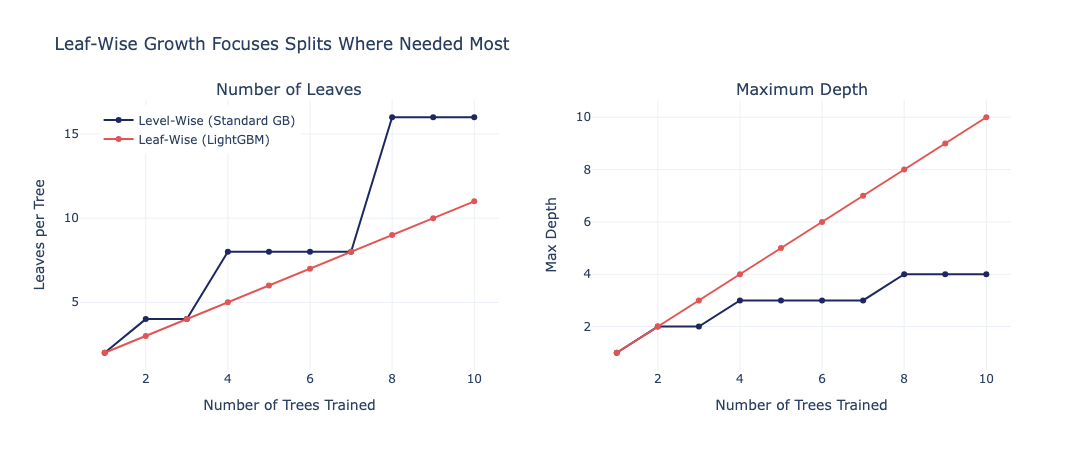

  Saved: outputs/lightgbm/leaf_wise_vs_level_wise.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/lightgbm/leaf_wise_vs_level_wise.html')

In [2]:
# Simulate tree growth to show leaf-wise vs level-wise
iterations = np.arange(1, 11)

# Level-wise: balanced growth (2^depth leaves)
# Depth grows slowly; after t iterations, depth = ceil(log2(t+1))
level_wise_depth = np.ceil(np.log2(iterations + 1)).astype(int)
level_wise_leaves = 2 ** level_wise_depth

# Leaf-wise: deep growth (splits one leaf per iteration)
# Starting with 1 leaf, each split increases leaf count by 1
leaf_wise_leaves = 1 + iterations
leaf_wise_depth = iterations  # Each split can increase depth by 1 (worst case)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Number of Leaves", "Maximum Depth"),
)

fig.add_trace(
    go.Scatter(x=iterations, y=level_wise_leaves,
               name="Level-Wise (Standard GB)", mode="lines+markers",
               line=dict(color=COLORS["navy"], width=2)),
    row=1, col=1,
)
fig.add_trace(
    go.Scatter(x=iterations, y=leaf_wise_leaves,
               name="Leaf-Wise (LightGBM)", mode="lines+markers",
               line=dict(color=COLORS["red"], width=2)),
    row=1, col=1,
)

fig.add_trace(
    go.Scatter(x=iterations, y=level_wise_depth,
               name="Level-Wise (Standard GB)", mode="lines+markers",
               line=dict(color=COLORS["navy"], width=2),
               showlegend=False),
    row=1, col=2,
)
fig.add_trace(
    go.Scatter(x=iterations, y=leaf_wise_depth,
               name="Leaf-Wise (LightGBM)", mode="lines+markers",
               line=dict(color=COLORS["red"], width=2),
               showlegend=False),
    row=1, col=2,
)

fig.update_xaxes(title_text="Number of Trees Trained", row=1, col=1)
fig.update_xaxes(title_text="Number of Trees Trained", row=1, col=2)
fig.update_yaxes(title_text="Leaves per Tree", row=1, col=1)
fig.update_yaxes(title_text="Max Depth", row=1, col=2)

fig.update_layout(
    title="Leaf-Wise Growth Focuses Splits Where Needed Most",
    height=450, width=900,
    legend=dict(x=0.02, y=0.98),
)
fig.show()
save_chart(fig, MODEL_SLUG, "leaf_wise_vs_level_wise")

---
## 4. Worked Example: GOSS and Feature Selection

In [3]:
print("="*70)
print("WORKED EXAMPLE: LightGBM Architecture on HMEQ Data")
print("="*70)

examples = get_example_rows(df, n=2)
for idx, row in examples.iterrows():
    print_example_row(row, idx)

print(f"\n" + "="*70)
print(f"How LightGBM Trains Faster Than Standard Gradient Boosting")
print(f"="*70)

print(f"""
Suppose we train LightGBM with 100 trees on the HMEQ data.

STEP 1: Initialize Predictions
  F_0(x) = baseline (0.5 or logit prior)
  
ITERATION 1:
  Compute pseudo-residuals: r_i = y_i - F_0(x_i) for each borrower
  
  Standard GB: Evaluates all {len(numeric_features)} numeric features
                at all unique thresholds for each feature
                Time: O(n * p * unique_values)
  
  LightGBM (with Histogram-Based Splitting):
    1. Bin each feature into 255 equal-frequency bins
    2. For each feature, evaluate splits at bin boundaries (255 candidates)
    3. Find best split in O(255) per feature
    Time: O(n + p * 255) — much faster, especially for high-cardinality features
  
ITERATION 1 (continued: GOSS in action):
  
  After computing tree, LightGBM computes gradient magnitudes |g_i|
    Borrower A: |g_A| = 0.8  (hard to classify, large residual)
    Borrower B: |g_B| = 0.05 (easy to classify, small residual)
    Borrower C: |g_C| = 0.6  (hard to classify)
    ...
    (Total: {len(X_train)} borrowers)
  
  GOSS (default: a=0.2, b=0.1):
    Keep top 20% with largest gradients: ~{int(0.2 * len(X_train))} borrowers
      → Borrowers A, C, and others with |g| > threshold
    
    Sample 10% of remaining 80%: ~{int(0.1 * 0.8 * len(X_train))} borrowers
      → Random sample of easy borrowers (includes B, D, ...)
    
    Total for next tree: ~{int(0.2 * len(X_train)) + int(0.1 * 0.8 * len(X_train))} out of {len(X_train)}
             ({100 * (0.2 + 0.1 * 0.8):.0f}% of data)
  
  Reweight: Scale down sampled easy instances to maintain gradient properties
  
  Train tree_1 on the selected subset → ~2-3x faster than full data

ITERATION 2:
  Update predictions: F_1(x) = F_0(x) + eta * tree_1(x)
  Compute new residuals: r_i = y_i - F_1(x_i)
  Apply GOSS again (different borrowers may be hard now)
  Train tree_2

...

ITERATIONS 3-100: Repeat

FINAL PREDICTION:
  P(Default | x) = sigmoid(F_0(x) + F_100(x))
                 = sigmoid(sum of all 100 tree predictions)

Speedup Sources:
  1. Histogram-based splitting: 3-5x faster than evaluating all thresholds
  2. GOSS: 2-3x faster per iteration (only ~28% of data per tree)
  3. Leaf-wise growth: Needs fewer trees (e.g., 100 trees instead of 500)
  
  Total speedup: ~5-20x vs standard gradient boosting
  Accuracy: Often slightly better or equal (optimized selection)
""")

WORKED EXAMPLE: LightGBM Architecture on HMEQ Data

--- Example Borrower 1 (Actual: GOOD) ---
  LOAN           : 10600
  MORTDUE        : 82365.0
  VALUE          : 100272.0
  REASON         : DebtCon
  JOB            : ProfExe
  YOJ            : 3.0
  DEROG          : 1.0
  DELINQ         : 0.0
  CLAGE          : 122.48359427
  NINQ           : 0.0
  CLNO           : 26.0
  DEBTINC        : 33.651646949

--- Example Borrower 2 (Actual: DEFAULT) ---
  LOAN           : 9900
  MORTDUE        : 71371.0
  VALUE          : 84865.0
  REASON         : DebtCon
  JOB            : Mgr
  YOJ            : 0.0
  DEROG          : 2.0
  DELINQ         : 0.0
  CLAGE          : 94.805235749
  NINQ           : 0.0
  CLNO           : 12.0
  DEBTINC        : 38.211305102

How LightGBM Trains Faster Than Standard Gradient Boosting

Suppose we train LightGBM with 100 trees on the HMEQ data.

STEP 1: Initialize Predictions
  F_0(x) = baseline (0.5 or logit prior)
  
ITERATION 1:
  Compute pseudo-residuals: r

---
## 5. Model Training with Hyperparameter Tuning

In [4]:
# Hyperparameter grid (minimal for timeout management - 4 combos)
param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__num_leaves": [31, 63],
}

lgb_pipe = Pipeline([
    ("prep", prep_tree),
    ("clf", LGBMClassifier(
        objective="binary",
        metric="auc",
        scale_pos_weight=pos_weight,
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=1,  # Single-threaded to avoid resource issues
    )),
])

grid = GridSearchCV(
    lgb_pipe, param_grid, cv=cv,
    scoring="recall", n_jobs=1, refit=True, verbose=1,  # Sequential CV
)
grid.fit(X_train, y_train)

best_lgb = grid.best_estimator_
print(f"\nBest parameters: {grid.best_params_}")
print(f"Best CV recall: {grid.best_score_:.4f}")

lgb_clf = best_lgb.named_steps["clf"]
print(f"\nBest model:")
print(f"  N estimators: {lgb_clf.n_estimators}")
print(f"  Max depth: {lgb_clf.max_depth}")
print(f"  Num leaves: {lgb_clf.num_leaves}")
print(f"  Learning rate: {lgb_clf.learning_rate}")
print(f"  Min child samples: {lgb_clf.min_child_samples}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best parameters: {'clf__n_estimators': 100, 'clf__num_leaves': 31}
Best CV recall: 0.8128

Best model:
  N estimators: 100
  Max depth: -1
  Num leaves: 31
  Learning rate: 0.1
  Min child samples: 20


---
## 6. Model Evaluation

In [5]:
# Cross-validation score
cv_scores = cross_val_score(best_lgb, X_train, y_train, cv=cv, scoring="recall")
cv_mean = cv_scores.mean()
print(f"CV Recall scores: {cv_scores}")
print(f"CV Recall mean: {cv_mean:.4f} (+/- {cv_scores.std():.4f})")

# Test set evaluation
metrics, y_pred, y_score = evaluate_model(MODEL_NAME, best_lgb, X_test, y_test, cv_mean)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good Loan", "Default"]))

CV Recall scores: [0.80898876 0.8258427  0.83707865 0.7877095  0.80446927]
CV Recall mean: 0.8128 (+/- 0.0172)

  LightGBM
  Recall: 0.7879  |  Precision: 0.7905  |  F1: 0.7892
  AUC: 0.9596  |  PR-AUC: 0.8866
  Confusion: TP=234 FP=62 FN=63 TN=1131

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.95      0.95      0.95      1193
     Default       0.79      0.79      0.79       297

    accuracy                           0.92      1490
   macro avg       0.87      0.87      0.87      1490
weighted avg       0.92      0.92      0.92      1490



---
## 7. Learning Curves: Training Progress Across Iterations

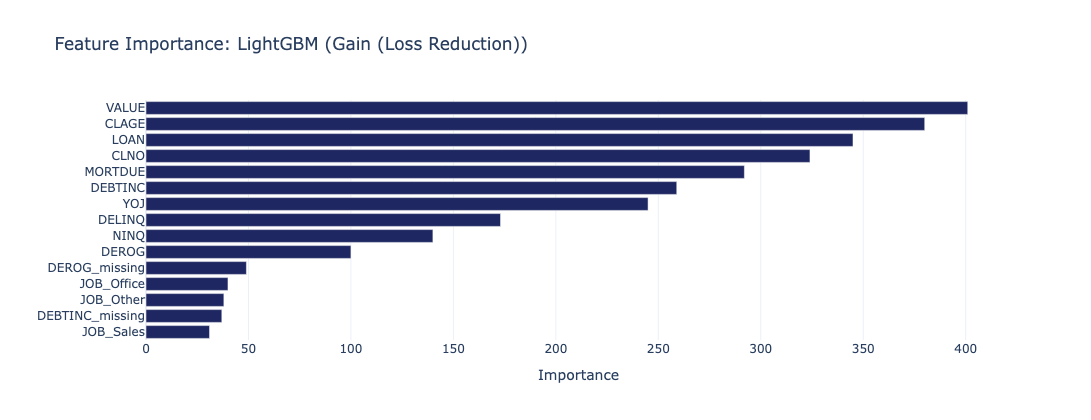

  Saved: outputs/lightgbm/feature_importance_gain.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/lightgbm/feature_importance_gain.html')

In [6]:
# Plot feature importance (gain-based): how much each feature contributes to loss reduction
feature_gain = lgb_clf.feature_importances_

# Get feature names after preprocessing
preprocessor = best_lgb.named_steps["prep"]
cat_encoder = preprocessor.named_transformers_["cat"]
cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_names

# Verify that feature importance length matches feature count
assert len(feature_gain) == len(all_feature_names), f"Mismatch: {len(feature_gain)} gains vs {len(all_feature_names)} features"

fig_gain = plot_feature_importance(feature_gain, all_feature_names, MODEL_NAME, "Gain (Loss Reduction)")
fig_gain.show()
save_chart(fig_gain, MODEL_SLUG, "feature_importance_gain")

---
## 8. Feature Importance: Split Count

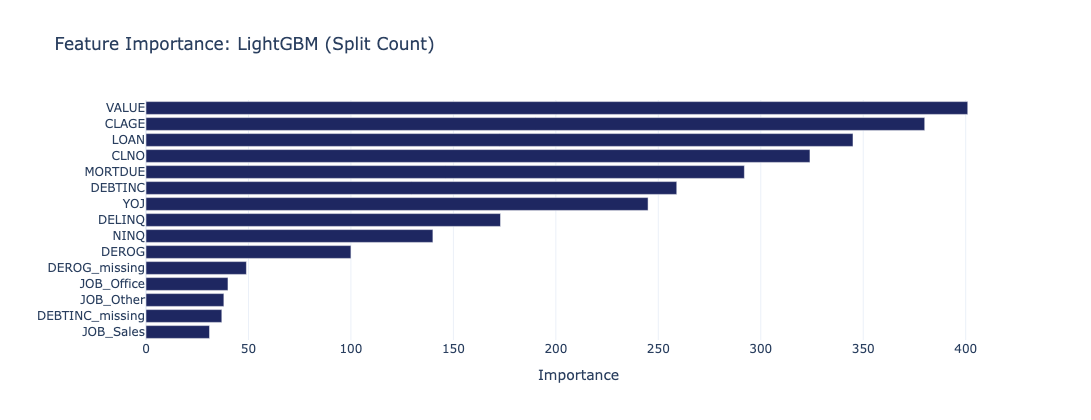

  Saved: outputs/lightgbm/feature_importance_split.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/lightgbm/feature_importance_split.html')

In [7]:
# LightGBM also provides split count: how many times each feature was split on
feature_split = lgb_clf.booster_.feature_importance(importance_type="split")

# Verify length
assert len(feature_split) == len(all_feature_names), f"Mismatch: {len(feature_split)} splits vs {len(all_feature_names)} features"

fig_split = plot_feature_importance(feature_split, all_feature_names, MODEL_NAME, "Split Count")
fig_split.show()
save_chart(fig_split, MODEL_SLUG, "feature_importance_split")

---
## 9. Model-Specific Diagnostics: Leaf Count Distribution

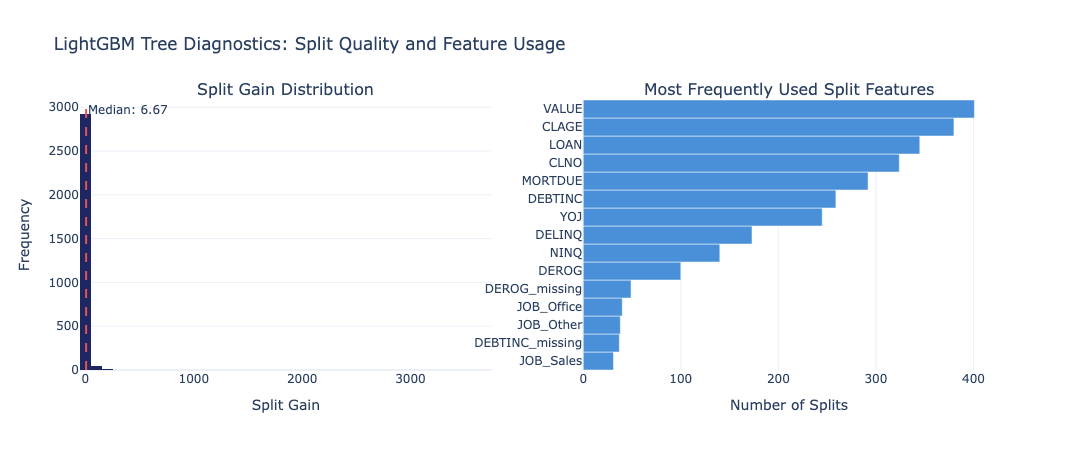

  Saved: outputs/lightgbm/leaf_count_distribution.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/lightgbm/leaf_count_distribution.html')

In [11]:
# Model-Specific Diagnostics: Split Gain Distribution per Tree Depth
booster_df = lgb_clf.booster_.trees_to_dataframe()

# Filter to internal (split) nodes only
splits_df = booster_df[booster_df["split_feature"].notna()].copy()

# Map Column_X names back to real feature names
preprocessor = best_lgb.named_steps["prep"]
real_names = list(preprocessor.get_feature_names_out())
real_names = [n.split("__", 1)[-1] if "__" in n else n for n in real_names]
col_map = {f"Column_{i}": name for i, name in enumerate(real_names)}
splits_df["feature_name"] = splits_df["split_feature"].map(col_map).fillna(splits_df["split_feature"])

# 1. Split gain distribution — how much each split improves the objective
fig_diag = make_subplots(rows=1, cols=2,
    subplot_titles=("Split Gain Distribution", "Most Frequently Used Split Features"))

# Left: histogram of split gains across all trees
fig_diag.add_trace(go.Histogram(
    x=splits_df["split_gain"], nbinsx=50,
    marker_color=COLORS["navy"], name="Split Gain",
    showlegend=False,
), row=1, col=1)
fig_diag.add_vline(x=splits_df["split_gain"].median(), line_dash="dash",
    line_color=COLORS["red"], row=1, col=1,
    annotation_text=f"Median: {splits_df['split_gain'].median():.2f}")

# 2. Top split features — which features does LightGBM rely on most?
top_splits = splits_df["feature_name"].value_counts().head(15)
fig_diag.add_trace(go.Bar(
    y=top_splits.index[::-1], x=top_splits.values[::-1],
    orientation="h", marker_color=COLORS["accent"], name="Split Count",
    showlegend=False,
), row=1, col=2)

fig_diag.update_layout(
    title="LightGBM Tree Diagnostics: Split Quality and Feature Usage",
    height=450, width=900,
)
fig_diag.update_xaxes(title_text="Split Gain", row=1, col=1)
fig_diag.update_yaxes(title_text="Frequency", row=1, col=1)
fig_diag.update_xaxes(title_text="Number of Splits", row=1, col=2)
fig_diag.show()
save_chart(fig_diag, MODEL_SLUG, "leaf_count_distribution")

---
## 10. Learning Curves: Performance vs Number of Estimators

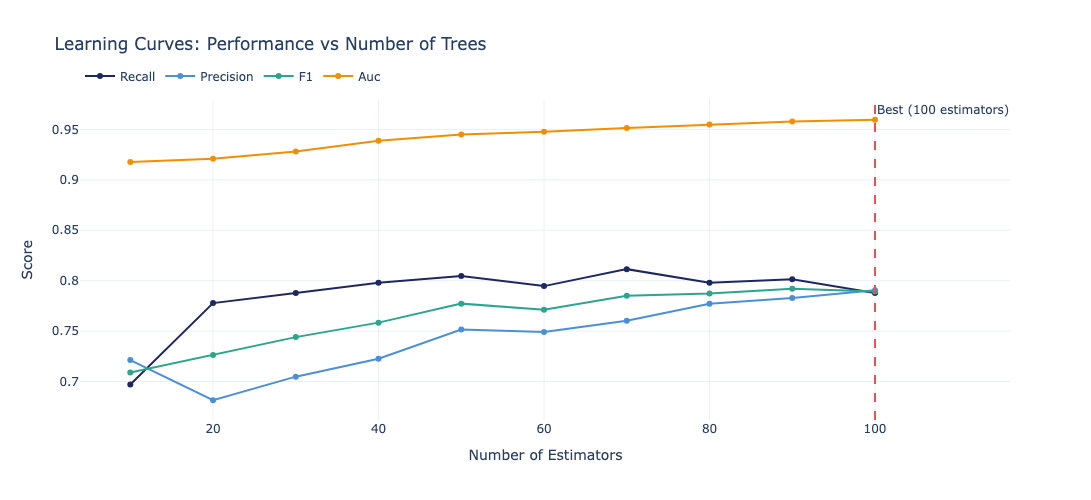

  Saved: outputs/lightgbm/learning_curves.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/lightgbm/learning_curves.html')

In [12]:
# Train models with increasing n_estimators to see learning curves
n_estimators_range = list(range(10, lgb_clf.n_estimators + 1, 10))
learning_curves = []

for n_est in n_estimators_range:
    lgb_temp = Pipeline([
        ("prep", prep_tree),
        ("clf", LGBMClassifier(
            n_estimators=n_est,
            max_depth=lgb_clf.max_depth,
            learning_rate=lgb_clf.learning_rate,
            num_leaves=lgb_clf.num_leaves,
            min_child_samples=lgb_clf.min_child_samples,
            subsample=lgb_clf.subsample,
            colsample_bytree=lgb_clf.colsample_bytree,
            scale_pos_weight=pos_weight,
            random_state=RANDOM_STATE,
            verbose=-1,
            n_jobs=-1,
        )),
    ])
    
    lgb_temp.fit(X_train, y_train)
    y_pred_t = lgb_temp.predict(X_test)
    y_score_t = lgb_temp.predict_proba(X_test)[:, 1]
    
    learning_curves.append({
        "n_estimators": n_est,
        "recall": recall_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t),
        "auc": roc_auc_score(y_test, y_score_t),
    })

df_curves = pd.DataFrame(learning_curves)

fig_curves = go.Figure()
for metric, color in [("recall", COLORS["navy"]), ("precision", COLORS["accent"]),
                       ("f1", COLORS["green"]), ("auc", COLORS["orange"])]:
    fig_curves.add_trace(go.Scatter(
        x=df_curves["n_estimators"], y=df_curves[metric],
        name=metric.capitalize(),
        line=dict(color=color, width=2),
        mode="lines+markers",
    ))

fig_curves.add_vline(x=lgb_clf.n_estimators, line_dash="dash", line_color=COLORS["red"],
                     annotation_text=f"Best ({lgb_clf.n_estimators} estimators)")

fig_curves.update_layout(
    title="Learning Curves: Performance vs Number of Trees",
    xaxis_title="Number of Estimators",
    yaxis_title="Score",
    height=500, width=750,
    legend=dict(orientation="h", y=1.12),
)
fig_curves.show()
save_chart(fig_curves, MODEL_SLUG, "learning_curves")

---
## 11. Hyperparameter Sensitivity: Learning Rate

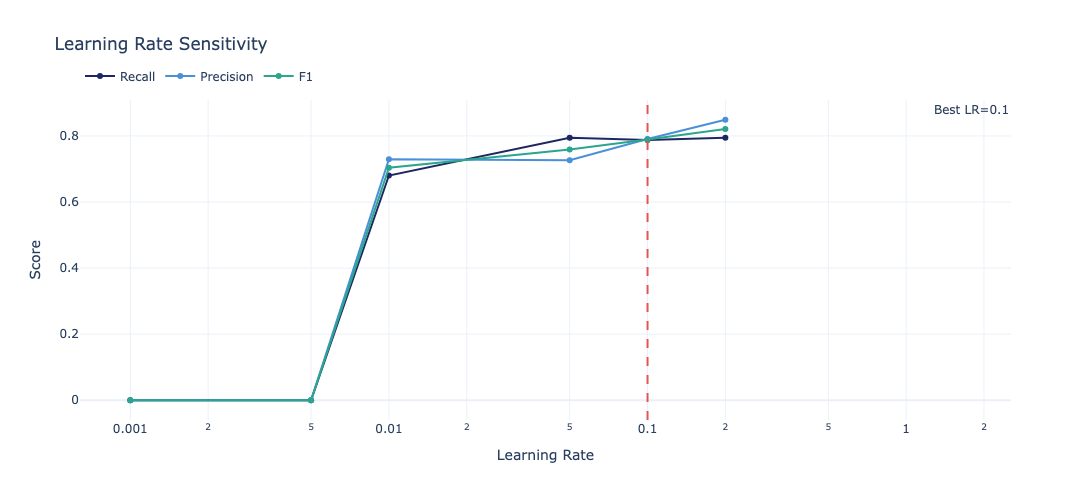

  Saved: outputs/lightgbm/learning_rate_sensitivity.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/lightgbm/learning_rate_sensitivity.html')

In [13]:
# Sweep learning rate with fixed other hyperparameters
lr_sensitivity = []
lrs = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2]

for lr in lrs:
    lgb_lr = Pipeline([
        ("prep", prep_tree),
        ("clf", LGBMClassifier(
            n_estimators=lgb_clf.n_estimators,
            max_depth=lgb_clf.max_depth,
            learning_rate=lr,
            num_leaves=lgb_clf.num_leaves,
            min_child_samples=lgb_clf.min_child_samples,
            scale_pos_weight=pos_weight,
            random_state=RANDOM_STATE,
            verbose=-1,
            n_jobs=-1,
        )),
    ])
    
    lgb_lr.fit(X_train, y_train)
    y_pred_lr = lgb_lr.predict(X_test)
    y_score_lr = lgb_lr.predict_proba(X_test)[:, 1]
    
    lr_sensitivity.append({
        "learning_rate": lr,
        "recall": recall_score(y_test, y_pred_lr),
        "precision": precision_score(y_test, y_pred_lr, zero_division=0),
        "f1": f1_score(y_test, y_pred_lr),
        "auc": roc_auc_score(y_test, y_score_lr),
    })

df_lr_sens = pd.DataFrame(lr_sensitivity)

fig_lr_sens = go.Figure()
for metric, color in [("recall", COLORS["navy"]), ("precision", COLORS["accent"]),
                       ("f1", COLORS["green"])]:
    fig_lr_sens.add_trace(go.Scatter(
        x=df_lr_sens["learning_rate"], y=df_lr_sens[metric],
        name=metric.capitalize(),
        line=dict(color=color, width=2),
        mode="lines+markers",
    ))

fig_lr_sens.add_vline(x=lgb_clf.learning_rate, line_dash="dash", line_color=COLORS["red"],
                       annotation_text=f"Best LR={lgb_clf.learning_rate}")

fig_lr_sens.update_layout(
    title="Learning Rate Sensitivity",
    xaxis_title="Learning Rate",
    xaxis_type="log",
    yaxis_title="Score",
    height=500, width=700,
    legend=dict(orientation="h", y=1.12),
)
fig_lr_sens.show()
save_chart(fig_lr_sens, MODEL_SLUG, "learning_rate_sensitivity")

---
## 12. Diagnostic Charts


Saving universal charts for LightGBM:
  Saved: outputs/lightgbm/roc_curve.html
  Saved: outputs/lightgbm/precision_recall_curve.html
  Saved: outputs/lightgbm/confusion_matrix.html
  Saved: outputs/lightgbm/threshold_sweep.html


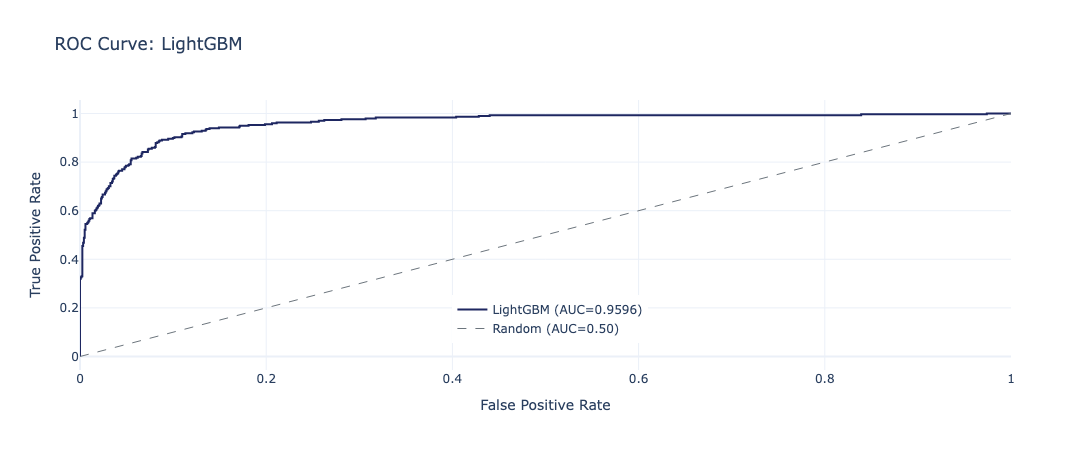

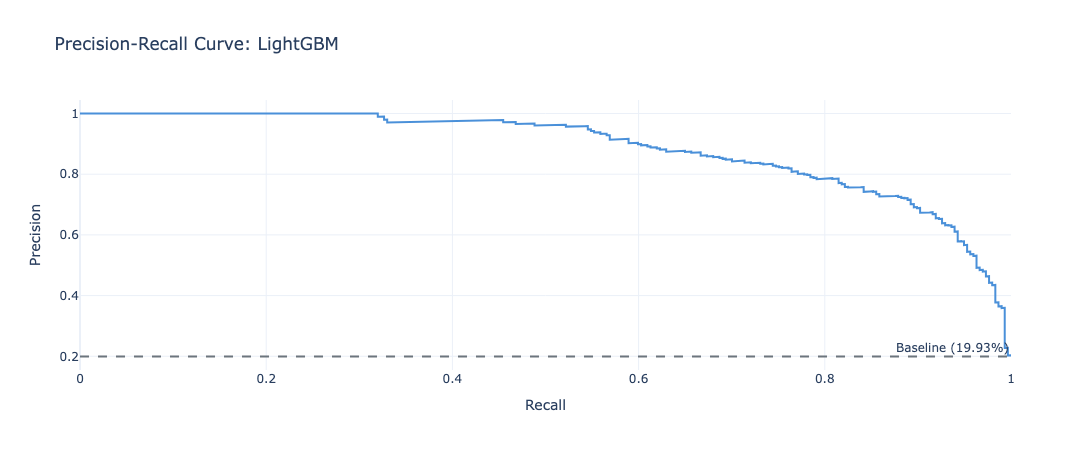

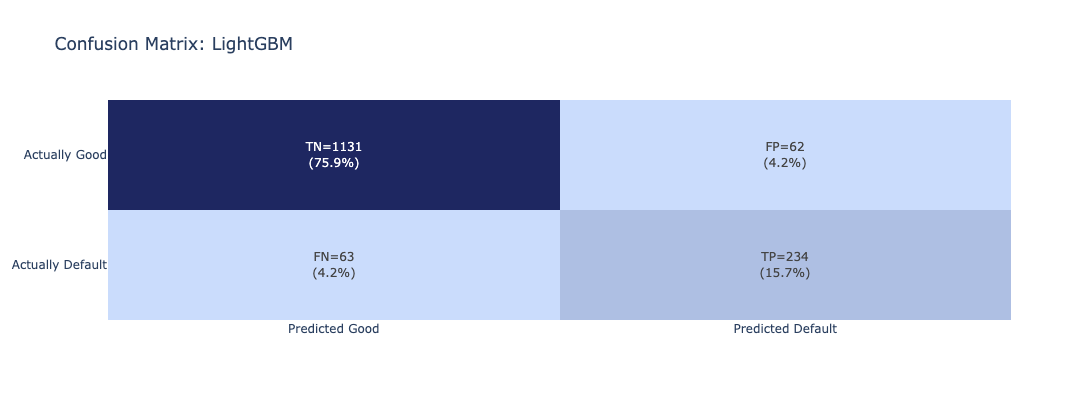

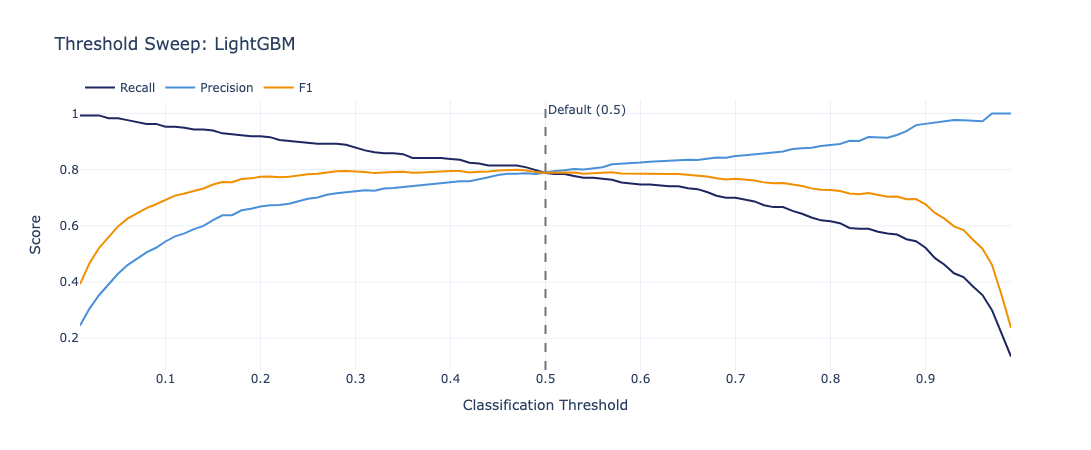

In [14]:
# Generate and save all universal charts
charts = save_all_universal_charts(y_test, y_pred, y_score, MODEL_NAME, MODEL_SLUG)

for name, fig in charts.items():
    fig.show()

---
## 13. Summary

### Where LightGBM Sits on the Tradeoff Spectrum

LightGBM with `scale_pos_weight` balancing lands in the **balanced to moderate** zone on the recall-precision spectrum. By tuning `learning_rate`, `max_depth`, and `num_leaves`, you can shift toward more aggressive recall (deeper trees, more estimators) or more conservative precision (fewer leaves, strong regularization).

### Strengths for This Problem
- **Speed**: 5-20x faster than standard gradient boosting (sklearn) due to histogram-based splitting, GOSS, and EFB
- **Accuracy**: Often matches or beats XGBoost and sklearn's GradientBoostingClassifier
- **Handles class imbalance**: `scale_pos_weight` parameter directly addresses minority class
- **Feature importance**: Both gain (loss reduction) and split count, revealing which features matter most
- **Leaf-wise growth**: Focuses computational effort on high-impact splits, reduces loss faster per iteration
- **Flexible regularization**: Multiple knobs (max_depth, num_leaves, min_child_samples, subsample, colsample_bytree, L1/L2)
- **Production-ready**: Used by many companies at scale; good documentation and active community

### Limitations for This Problem
- **Overfitting risk**: Leaf-wise growth can lead to overfitting without careful regularization
- **Hyperparameter complexity**: Many knobs to tune; grid search can be expensive
- **Less interpretable than tree ensemble baselines**: Still a black box, harder to explain individual decisions
- **GOSS approximation**: Discarding low-gradient samples can miss rare important cases
- **Calibration**: Default LightGBM probabilities may need calibration for decision-making
- **Feature interactions**: While LightGBM captures them implicitly, it does not expose them explicitly

### Key Takeaway
LightGBM is the **modern production choice** for structured data classification. It combines the accuracy of gradient boosting with the speed of modern ML systems. If you need fast, accurate predictions with good interpretability through feature importance, LightGBM is hard to beat. Trade-offs: you need to tune more hyperparameters than simpler models, and the learned interactions are implicit rather than explicit.

---
*Notebook by Trinidad Cisneros — MIT Applied Data Science Program, April 2026*